In [6]:
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def load_train(path, dataframe):

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        horizontal_flip=True,
        validation_split=0.2
    )

    train_data = train_datagen.flow_from_dataframe(
        dataframe=dataframe,
        directory=path,
        x_col='file_name',
        y_col='real_age',
        target_size=(224,224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_data


def load_test(path, dataframe):

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2
    )

    val_data = val_datagen.flow_from_dataframe(
        dataframe=dataframe,
        directory=path,
        x_col='file_name',
        y_col='real_age',
        target_size=(224,224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return val_data


def create_model(input_shape):

    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )

    backbone.trainable = False

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model


def train_model(model, train_data, test_data, epochs=10):
    
    early_stopping = EarlyStopping(
        monitor='val_mae',
        patience=2,
        restore_best_weights=True
    )
    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        verbose=2
    )

    print("Fase 2: Fine-Tuning")

    backbone = model.layers[0]
    backbone.trainable = True

    for layer in backbone.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),  
        loss='mean_squared_error',
        metrics=['mae']
    )

    model.fit(
        train_data,
        validation_data=test_data,
        epochs=10,
        callbacks=[early_stopping],
        verbose=2
    )

    return model


if __name__ == "__main__":

    print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

    dataframe = pd.read_csv('faces_dataset/labels.csv')
    path = 'faces_dataset/final_files/'

    train_gen = load_train(path, dataframe)
    val_gen = load_test(path, dataframe)

    input_shape = (224,224,3)
    model = create_model(input_shape)

    trained_model = train_model(model, train_gen, val_gen)


    print("Entrenamiento finalizado.")

GPUs disponibles: []
Found 6073 validated image filenames.
Found 1518 validated image filenames.


C:\Users\pirom\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
190/190 - 185s - 975ms/step - loss: 399.5421 - mae: 15.2837 - val_loss: 249.3237 - val_mae: 12.4985
Epoch 2/10
190/190 - 180s - 947ms/step - loss: 246.0271 - mae: 12.1641 - val_loss: 195.4646 - val_mae: 11.3146
Epoch 3/10
190/190 - 180s - 946ms/step - loss: 210.5309 - mae: 11.2350 - val_loss: 171.9745 - val_mae: 10.5473
Epoch 4/10
190/190 - 182s - 956ms/step - loss: 197.0405 - mae: 10.8322 - val_loss: 165.0385 - val_mae: 10.4346
Epoch 5/10
190/190 - 180s - 947ms/step - loss: 189.2054 - mae: 10.6275 - val_loss: 161.8320 - val_mae: 10.3548
Epoch 6/10
190/190 - 189s - 993ms/step - loss: 181.7350 - mae: 10.4541 - val_loss: 150.3176 - val_mae: 9.8320
Epoch 7/10
190/190 - 187s - 982ms/step - loss: 174.6970 - mae: 10.2222 - val_loss: 148.3964 - val_mae: 9.8112
Epoch 8/10
190/190 - 188s - 990ms/step - loss: 173.4743 - mae: 10.1765 - val_loss: 141.9315 - val_mae: 9.4415
Epoch 9/10
190/190 - 193s - 1s/step - loss: 167.2789 - mae: 9.9666 - val_loss: 146.5277 - val_mae: 9.7764
Epoch 10/

In [8]:
import numpy as np

images, real_ages = next(val_gen)

predicted_ages = trained_model.predict(images)

# Mostrar algunos ejemplos
for i in range(10):
    print(f"Edad real: {real_ages[i]:.1f} | Edad predicha: {predicted_ages[i][0]:.1f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Edad real: 3.0 | Edad predicha: 22.0
Edad real: 34.0 | Edad predicha: 26.4
Edad real: 28.0 | Edad predicha: 27.7
Edad real: 19.0 | Edad predicha: 27.8
Edad real: 36.0 | Edad predicha: 45.1
Edad real: 41.0 | Edad predicha: 41.4
Edad real: 48.0 | Edad predicha: 44.4
Edad real: 17.0 | Edad predicha: 11.9
Edad real: 8.0 | Edad predicha: 24.3
Edad real: 44.0 | Edad predicha: 19.4


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..70.5305].


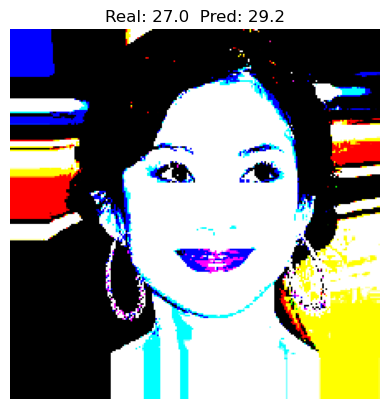

In [14]:
import matplotlib.pyplot as plt

plt.imshow((images[0] + 1) / 2)
plt.title(f"Real: {real_ages[0]:.1f}  Pred: {predicted_ages[0][0]:.1f}")
plt.axis("off")
plt.show()